0. Setup Awal

In [50]:
import os
import time
import tracemalloc
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')

plt.style.use(
    'seaborn-v0_8-whitegrid'
    if 'seaborn-v0_8-whitegrid' in plt.style.available
    else 'default'
)

plt.rcParams['figure.dpi'] = 120

OUTPUT_DIR = 'outputDBSCANEuclidian'
os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

1. Data Understanding

1.1 Load Dataset

In [51]:
df = pd.read_csv('burnout_dataset1.csv')

print(f'Jumlah data awal: {len(df)}')

# df = df.sample(
#     n=5000,
#     random_state=42
# ).reset_index(drop=True)
# print(f'Jumlah data setelah sampling: {len(df)}')

Jumlah data awal: 50000


1.2 Data Preview

In [52]:
print("5 Baris Pertama Dataset:")
display(df.head())

print("\nNama Semua Kolom:")
print(df.columns.tolist())

5 Baris Pertama Dataset:


,Person_ID,Age,Gender,Country,Occupation,Education_Level,Employment_Status,Monthly_Income_USD,Work_Hours_Per_Week,Remote_Work,...,Family_History_Mental_Illness,Therapy_Attendance,Support_System,Life_Satisfaction,Productivity_Score,Absenteeism_Days,Burnout_Score,Mental_Health_Status,AI_Wellness_Recommendation,Burnout_Risk
0,1,58.0,Male,United States,Marketing Manager,Diploma,Employed,2786.0,67,Hybrid,...,No,Yes,Average,6.0,19.0,2,82,Critical,Practice Mindfulness,High
1,2,24.0,Female,Pakistan,Freelancer,Bachelor,Student,8027.0,44,Hybrid,...,Yes,No,Good,4.0,27.0,22,64,Critical,Reduce Workload,Moderate
2,3,59.0,Male,Malaysia,Accountant,PhD,Employed,3177.0,60,No,...,Yes,No,Average,4.0,51.0,17,50,Needs Attention,Increase Physical Activity,Moderate
3,4,65.0,Other,Mexico,Chef,Master,Self-Employed,4093.0,25,Yes,...,No,Yes,Good,7.0,83.0,14,16,Healthy,Maintain Healthy Routine,Low
4,5,64.0,Other,Japan,Farmer,Diploma,Student,NaN,52,No,...,Yes,No,Poor,9.0,61.0,4,26,Healthy,Reduce Workload,Low



Nama Semua Kolom:
['Person_ID', 'Age', 'Gender', 'Country', 'Occupation', 'Education_Level', 'Employment_Status', 'Monthly_Income_USD', 'Work_Hours_Per_Week', 'Remote_Work', 'Job_Satisfaction', 'Work_Life_Balance', 'Sleep_Hours', 'Sleep_Quality', 'Stress_Level', 'Anxiety_Score', 'Depression_Score', 'Mood_Score', 'Emotional_Stability', 'Physical_Activity_Hours', 'Exercise_Frequency', 'Meditation_Minutes', 'Screen_Time_Hours', 'Social_Media_Hours', 'Gaming_Hours', 'Coffee_Cups_Per_Day', 'Alcohol_Consumption', 'Smoking', 'Healthy_Diet', 'Chronic_Stress', 'Family_History_Mental_Illness', 'Therapy_Attendance', 'Support_System', 'Life_Satisfaction', 'Productivity_Score', 'Absenteeism_Days', 'Burnout_Score', 'Mental_Health_Status', 'AI_Wellness_Recommendation', 'Burnout_Risk']


1.3 Tipe data dan Missing Values

In [53]:
print('Tipe Data:')
print(df.dtypes)

print('\nJumlah Missing Value:')
missing = df.isnull().sum()

missing[missing > 0]

Tipe Data:
Person_ID                          int64
Age                              float64
Gender                               str
Country                              str
Occupation                           str
Education_Level                      str
Employment_Status                    str
Monthly_Income_USD               float64
Work_Hours_Per_Week                int64
Remote_Work                          str
Job_Satisfaction                 float64
Work_Life_Balance                float64
Sleep_Hours                      float64
Sleep_Quality                        str
Stress_Level                         str
Anxiety_Score                    float64
Depression_Score                 float64
Mood_Score                       float64
Emotional_Stability                int64
Physical_Activity_Hours          float64
Exercise_Frequency                   str
Meditation_Minutes               float64
Screen_Time_Hours                float64
Social_Media_Hours               float64
Gamin

Age                         250
Monthly_Income_USD         1450
Job_Satisfaction            500
Work_Life_Balance           650
Sleep_Hours                 950
Anxiety_Score               800
Depression_Score            850
Mood_Score                  900
Physical_Activity_Hours    1100
Meditation_Minutes         1200
Screen_Time_Hours           850
Social_Media_Hours          600
Gaming_Hours                750
Therapy_Attendance          400
Life_Satisfaction           700
Productivity_Score          950
dtype: int64

1.4 Identifikasi Kolom yang Digunakan

In [54]:
# Kolom numerik asli
numeric_columns = df.select_dtypes(
    include='number'
).columns

# Kolom kategorikal
categorical_columns = df.select_dtypes(
    include=['object', 'category']
).columns

print('Kolom Numerik:')
print(
    numeric_columns.tolist()
)

print(
    '\nKolom Kategorikal yang akan di-encoding:'
)
print(
    categorical_columns
)

Kolom Numerik:
['Person_ID', 'Age', 'Monthly_Income_USD', 'Work_Hours_Per_Week', 'Job_Satisfaction', 'Work_Life_Balance', 'Sleep_Hours', 'Anxiety_Score', 'Depression_Score', 'Mood_Score', 'Emotional_Stability', 'Physical_Activity_Hours', 'Meditation_Minutes', 'Screen_Time_Hours', 'Social_Media_Hours', 'Gaming_Hours', 'Coffee_Cups_Per_Day', 'Life_Satisfaction', 'Productivity_Score', 'Absenteeism_Days', 'Burnout_Score']

Kolom Kategorikal yang akan di-encoding:
Index(['Gender', 'Country', 'Occupation', 'Education_Level',
       'Employment_Status', 'Remote_Work', 'Sleep_Quality', 'Stress_Level',
       'Exercise_Frequency', 'Alcohol_Consumption', 'Smoking', 'Healthy_Diet',
       'Chronic_Stress', 'Family_History_Mental_Illness', 'Therapy_Attendance',
       'Support_System', 'Mental_Health_Status', 'AI_Wellness_Recommendation',
       'Burnout_Risk'],
      dtype='str')


1.5 Statistik Deskriptif

In [55]:
df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Person_ID,50000.0,25000.500000,14433.901067,1.0,12500.75,25000.5,37500.25,50000.0
Age,49750.0,41.448181,13.871634,18.0,29.00,41.0,53.00,65.0
Monthly_Income_USD,48550.0,6251.281524,3319.661435,500.0,3381.00,6231.0,9134.00,12000.0
Work_Hours_Per_Week,50000.0,44.946160,14.729024,20.0,32.00,45.0,58.00,70.0
Job_Satisfaction,49500.0,5.499051,2.866621,1.0,3.00,6.0,8.00,10.0
Work_Life_Balance,49350.0,5.504397,2.867492,1.0,3.00,6.0,8.00,10.0
Sleep_Hours,49050.0,6.997445,1.728766,4.0,5.50,7.0,8.50,10.0
Anxiety_Score,49200.0,40.449045,26.004291,0.0,19.00,39.0,59.00,100.0
Depression_Score,49150.0,40.601160,26.308933,0.0,19.00,39.0,60.00,100.0
Mood_Score,49100.0,59.622994,25.783486,0.0,41.00,61.0,80.00,100.0


1.6 Visualisasi Distribusi Data

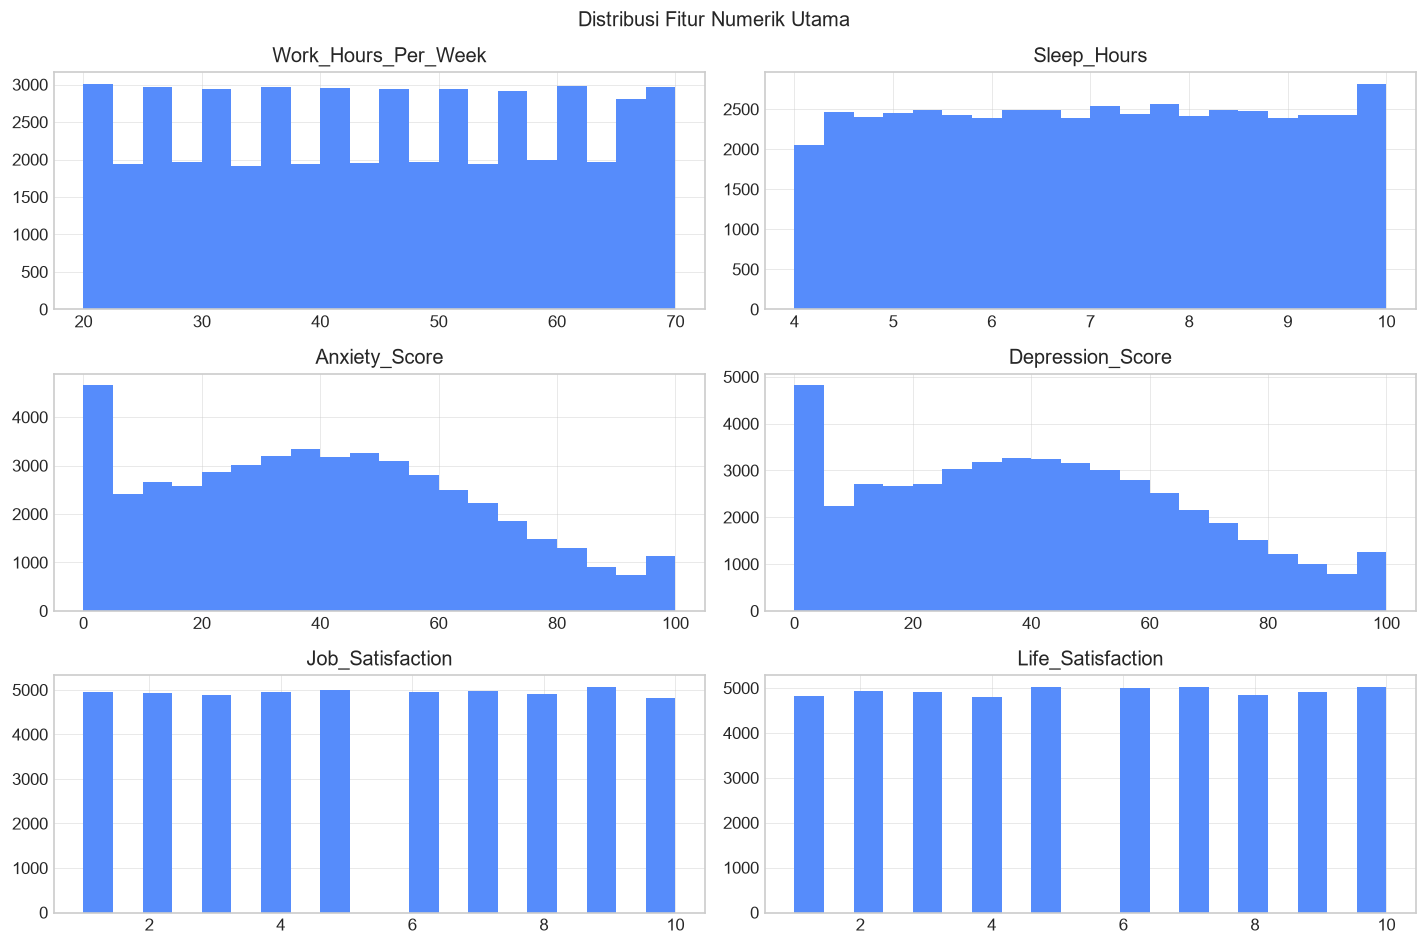

In [56]:
selected_features = [
    'Work_Hours_Per_Week',
    'Sleep_Hours',
    'Anxiety_Score',
    'Depression_Score',
    'Job_Satisfaction',
    'Life_Satisfaction'
]

df[selected_features].hist(
    figsize=(12, 8),
    bins=20
)

plt.suptitle('Distribusi Fitur Numerik Utama')
plt.tight_layout()
plt.show()

1.7 Visualisasi Deteksi Outlier

In [57]:
numeric_columns = df.select_dtypes(include='number').columns

numeric_columns = numeric_columns.drop(
    ['person_id', 'Person_ID'],
    errors='ignore'
)

numeric_data = df[numeric_columns]

Q1 = numeric_data.quantile(0.25)
Q3 = numeric_data.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = (
    (numeric_data < lower_bound) |
    (numeric_data > upper_bound)
)

In [58]:
outlier_summary = pd.DataFrame({
    'Jumlah Outlier': outlier_mask.sum(),
    'Persentase (%)': (
        outlier_mask.sum() / len(df) * 100
    ).round(2)
})

outlier_summary = outlier_summary.sort_values(
    'Jumlah Outlier',
    ascending=False
)

outlier_summary

,Jumlah Outlier,Persentase (%)
Age,0,0.0
Monthly_Income_USD,0,0.0
Work_Hours_Per_Week,0,0.0
Job_Satisfaction,0,0.0
Work_Life_Balance,0,0.0
Sleep_Hours,0,0.0
Anxiety_Score,0,0.0
Depression_Score,0,0.0
Mood_Score,0,0.0
Emotional_Stability,0,0.0


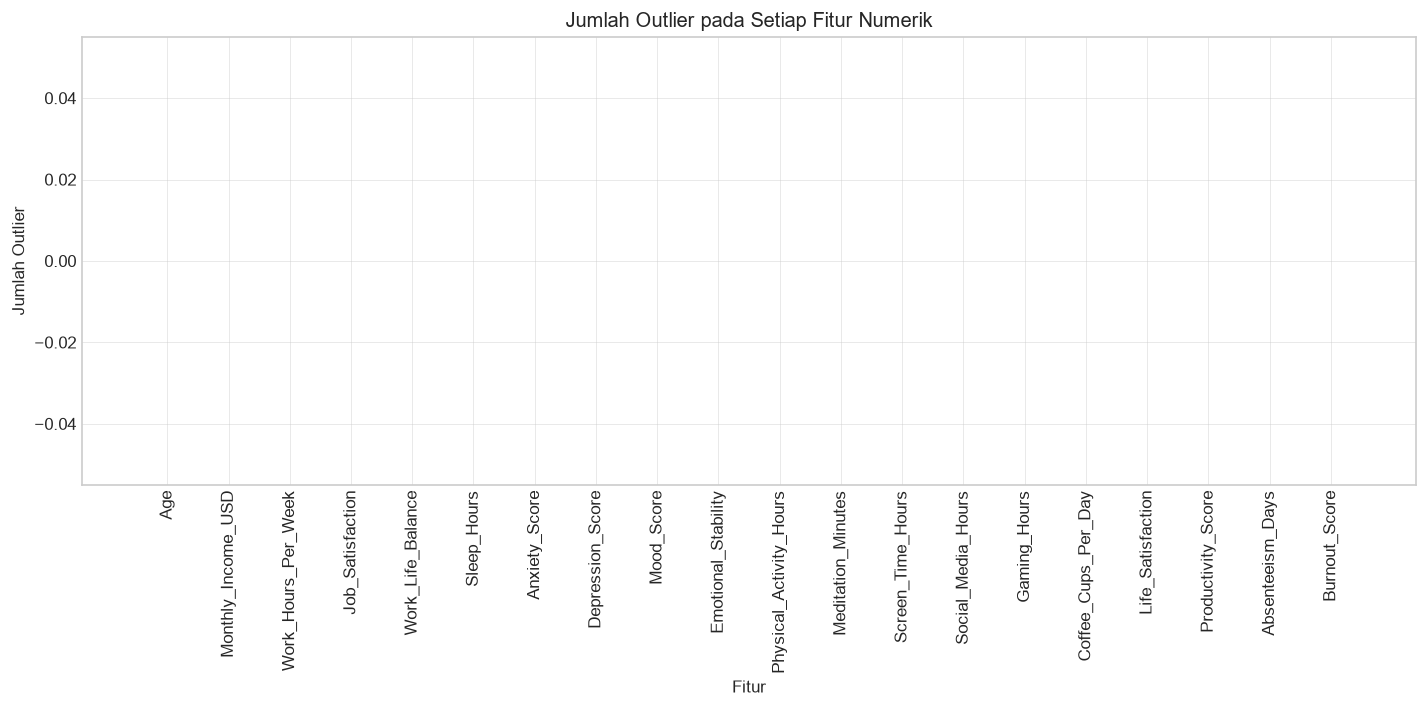

In [59]:
plt.figure(figsize=(12, 6))

plt.bar(
    outlier_summary.index,
    outlier_summary['Jumlah Outlier']
)

plt.title('Jumlah Outlier pada Setiap Fitur Numerik')
plt.xlabel('Fitur')
plt.ylabel('Jumlah Outlier')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

2.1 Seleksi Kolom

In [60]:
# Drop beberapa kolom yang tidak perlu
numeric_columns = numeric_columns.drop(
    ['Burnout_Score'],
    errors='ignore'
)

categorical_columns = categorical_columns.drop(
    [
        'Gender',
        'Country',
        'Occupation',
        'AI_Wellness_Recommendation',
        'Burnout_Risk',
        'Education_Level',
        'Employment_Status'
    ],
    errors='ignore'
)

selected_columns = (
    list(numeric_columns)
    + list(categorical_columns)
)

X = df[
    selected_columns
].copy()

X.head()

,Age,Monthly_Income_USD,Work_Hours_Per_Week,Job_Satisfaction,Work_Life_Balance,Sleep_Hours,Anxiety_Score,Depression_Score,Mood_Score,Emotional_Stability,...,Stress_Level,Exercise_Frequency,Alcohol_Consumption,Smoking,Healthy_Diet,Chronic_Stress,Family_History_Mental_Illness,Therapy_Attendance,Support_System,Mental_Health_Status
0,58.0,2786.0,67,3.0,7.0,4.6,74.0,75.0,26.0,18,...,High,Weekly,Yes,Yes,No,Yes,No,Yes,Average,Critical
1,24.0,8027.0,44,5.0,8.0,4.7,58.0,80.0,29.0,37,...,Moderate,Weekly,Yes,Yes,Yes,No,Yes,No,Good,Critical
2,59.0,3177.0,60,8.0,7.0,6.3,54.0,55.0,44.0,48,...,Moderate,Daily,Yes,No,No,No,Yes,No,Average,Needs Attention
3,65.0,4093.0,25,2.0,9.0,7.1,12.0,11.0,88.0,80,...,Low,Weekly,Yes,No,No,No,No,Yes,Good,Healthy
4,64.0,NaN,52,1.0,4.0,9.1,25.0,48.0,67.0,76,...,Low,Never,Yes,No,No,No,Yes,No,Poor,Healthy


2.2 Encoding Data Kategorikal

In [61]:
encoding_maps = {
    'Remote_Work': {
        'No': 0,
        'Hybrid': 1,
        'Yes': 2
    },

    'Sleep_Quality': {
        'Excellent': 0,
        'Good': 1,
        'Average': 2,
        'Poor': 3
    },

    'Stress_Level': {
        'Low': 0,
        'Moderate': 1,
        'High': 2
    },

    'Exercise_Frequency': {
        'Daily': 0,
        'Weekly': 1,
        'Rarely': 2,
        'Never': 3
    },

    'Alcohol_Consumption': {
        'No': 0,
        'Yes': 1
    },

    'Smoking': {
        'No': 0,
        'Yes': 1
    },

    'Healthy_Diet': {
        'No': 1,
        'Yes': 0
    },

    'Chronic_Stress': {
        'No': 0,
        'Yes': 1
    },

    'Family_History_Mental_Illness': {
        'No': 0,
        'Yes': 1
    },

    'Therapy_Attendance': {
        'No': 1,
        'Yes': 0
    },

    'Support_System': {
        'Poor': 3,
        'Average': 2,
        'Good': 1,
        'Excellent': 0
    },

    'Mental_Health_Status': {
        'Healthy': 0,
        'Needs Attention': 1,
        'Critical': 2
    }
}

for column, mapping in encoding_maps.items():

    X[column] = (
        X[column]
        .map(mapping)
    )

X[categorical_columns].head()

,Remote_Work,Sleep_Quality,Stress_Level,Exercise_Frequency,Alcohol_Consumption,Smoking,Healthy_Diet,Chronic_Stress,Family_History_Mental_Illness,Therapy_Attendance,Support_System,Mental_Health_Status
0,1,3,2,1,1,1,1,1,0,0.0,2,2
1,1,3,1,1,1,1,0,0,1,1.0,1,2
2,0,2,1,0,1,0,1,0,1,1.0,2,1
3,2,1,0,1,1,0,1,0,0,0.0,1,0
4,0,0,0,3,1,0,1,0,1,1.0,3,0


2.3 Penanganan Missing Values

In [62]:
print(
    'Missing value sebelum preprocessing:'
)

print(
    X.isnull().sum()
)

X = X.fillna(
    X.mean()
)

print(
    '\nJumlah missing value setelah preprocessing:'
)

print(
    X.isnull().sum()
)

Missing value sebelum preprocessing:
Age                               250
Monthly_Income_USD               1450
Work_Hours_Per_Week                 0
Job_Satisfaction                  500
Work_Life_Balance                 650
Sleep_Hours                       950
Anxiety_Score                     800
Depression_Score                  850
Mood_Score                        900
Emotional_Stability                 0
Physical_Activity_Hours          1100
Meditation_Minutes               1200
Screen_Time_Hours                 850
Social_Media_Hours                600
Gaming_Hours                      750
Coffee_Cups_Per_Day                 0
Life_Satisfaction                 700
Productivity_Score                950
Absenteeism_Days                    0
Remote_Work                         0
Sleep_Quality                       0
Stress_Level                        0
Exercise_Frequency                  0
Alcohol_Consumption                 0
Smoking                             0
Healthy_Diet 

2.4 Penanganan Outlier

In [63]:
# Karena tidak, tidak dilakukan

2.5 Standardisasi

In [64]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X
)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns,
    index=X.index
)

X_scaled

,Age,Monthly_Income_USD,Work_Hours_Per_Week,Job_Satisfaction,Work_Life_Balance,Sleep_Hours,Anxiety_Score,Depression_Score,Mood_Score,Emotional_Stability,...,Stress_Level,Exercise_Frequency,Alcohol_Consumption,Smoking,Healthy_Diet,Chronic_Stress,Family_History_Mental_Illness,Therapy_Attendance,Support_System,Mental_Health_Status
0,1.196220,-1.059350,1.497320,-0.876176,0.525001,-1.400175,1.300669,1.318767,-1.315962,-1.586087,...,1.838578,-0.455507,1.008436,1.003687,0.996685,2.53389,-0.996765,-1.012603,0.441976,1.633584
1,-1.261001,0.542844,-0.064238,-0.174969,0.876030,-1.341772,0.680397,1.510455,-1.198546,-0.857858,...,0.411952,-0.455507,1.008436,1.003687,-1.003326,-0.39465,1.003245,0.995518,-0.452894,1.633584
2,1.268491,-0.939820,1.022063,0.876842,0.525001,-0.407328,0.525329,0.552016,-0.611465,-0.436251,...,0.411952,-1.351150,1.008436,-0.996327,0.996685,-0.39465,1.003245,0.995518,0.441976,0.373764
3,1.702118,-0.659795,-1.354221,-1.226780,1.227060,0.059895,-1.102883,-1.134836,1.110641,0.790240,...,-1.014673,-0.455507,1.008436,-0.996327,0.996685,-0.39465,-0.996765,-1.012603,-0.452894,-0.886057
4,1.629847,0.000000,0.478912,-1.577384,-0.528088,1.227951,-0.598913,0.283653,0.288727,0.636928,...,-1.014673,1.335781,1.008436,-0.996327,0.996685,-0.39465,1.003245,0.995518,1.336847,-0.886057
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,-0.393747,-0.828849,-0.132132,0.876842,0.173971,0.001492,0.641630,0.321991,-0.572326,-0.551235,...,0.411952,-0.455507,1.008436,-0.996327,-1.003326,-0.39465,1.003245,0.995518,0.441976,0.373764
49996,1.123948,1.338592,-1.422115,-1.226780,0.173971,-1.575383,-1.335485,-1.556549,1.306335,1.556797,...,-1.014673,-1.351150,1.008436,1.003687,0.996685,-0.39465,-0.996765,-1.012603,-1.347764,-0.886057
49997,-0.538289,-0.950214,0.750488,0.876842,-1.230147,0.351909,0.951766,1.433780,-1.041991,-1.011169,...,0.411952,1.335781,1.008436,-0.996327,-1.003326,-0.39465,-0.996765,-1.012603,1.336847,1.633584
49998,1.413033,-0.755175,-1.082646,-0.174969,0.525001,0.001492,-0.327544,-0.904811,0.562698,0.100338,...,-1.014673,1.335781,1.008436,1.003687,0.996685,-0.39465,-0.996765,-1.012603,1.336847,-0.886057


2.6 Data Bersih

In [65]:
print('Dimensi data setelah preprocessing:', X.shape)
print('Jumlah missing value:', X.isnull().sum().sum())

X_scaled.head()

Dimensi data setelah preprocessing: (50000, 31)
Jumlah missing value: 0


,Age,Monthly_Income_USD,Work_Hours_Per_Week,Job_Satisfaction,Work_Life_Balance,Sleep_Hours,Anxiety_Score,Depression_Score,Mood_Score,Emotional_Stability,...,Stress_Level,Exercise_Frequency,Alcohol_Consumption,Smoking,Healthy_Diet,Chronic_Stress,Family_History_Mental_Illness,Therapy_Attendance,Support_System,Mental_Health_Status
0,1.196220,-1.059350,1.497320,-0.876176,0.525001,-1.400175,1.300669,1.318767,-1.315962,-1.586087,...,1.838578,-0.455507,1.008436,1.003687,0.996685,2.53389,-0.996765,-1.012603,0.441976,1.633584
1,-1.261001,0.542844,-0.064238,-0.174969,0.876030,-1.341772,0.680397,1.510455,-1.198546,-0.857858,...,0.411952,-0.455507,1.008436,1.003687,-1.003326,-0.39465,1.003245,0.995518,-0.452894,1.633584
2,1.268491,-0.939820,1.022063,0.876842,0.525001,-0.407328,0.525329,0.552016,-0.611465,-0.436251,...,0.411952,-1.351150,1.008436,-0.996327,0.996685,-0.39465,1.003245,0.995518,0.441976,0.373764
3,1.702118,-0.659795,-1.354221,-1.226780,1.227060,0.059895,-1.102883,-1.134836,1.110641,0.790240,...,-1.014673,-0.455507,1.008436,-0.996327,0.996685,-0.39465,-0.996765,-1.012603,-0.452894,-0.886057
4,1.629847,0.000000,0.478912,-1.577384,-0.528088,1.227951,-0.598913,0.283653,0.288727,0.636928,...,-1.014673,1.335781,1.008436,-0.996327,0.996685,-0.39465,1.003245,0.995518,1.336847,-0.886057


3. Modeling

3.1 Penentuan Parameter DBSCAN dengan K-Distance

In [66]:
min_samples = 10

neighbors = NearestNeighbors(
    n_neighbors=min_samples,
    metric='euclidean'
)

neighbors_fit = neighbors.fit(
    X_scaled
)

distances, indices = (
    neighbors_fit.kneighbors(
        X_scaled
    )
)

k_distances = np.sort(
    distances[:, -1]
)

print(
    'Jumlah data:',
    len(k_distances)
)

print(
    'Minimum K-Distance:',
    k_distances.min()
)

print(
    'Maximum K-Distance:',
    k_distances.max()
)

Jumlah data: 50000
Minimum K-Distance: 3.2420064203608825
Maximum K-Distance: 5.096319194267402


3.1.1 Menghitung K-Distance

In [67]:
percentiles = [
    10,
    20,
    30,
    40,
    50,
    60,
    70,
    75,
    80,
    85,
    90,
    92,
    94,
    96
]

eps_candidates = np.percentile(
    k_distances,
    percentiles
)

eps_candidates_df = pd.DataFrame({
    'Percentile':
        percentiles,

    'eps':
        eps_candidates
})

eps_candidates_df

,Percentile,eps
0,10,3.762901
1,20,3.856147
2,30,3.924922
3,40,3.983826
4,50,4.042347
5,60,4.100549
6,70,4.164703
7,75,4.201057
8,80,4.240673
9,85,4.287808


3.1.2 Menentukan Kandidat eps

In [68]:
experiment_results = []

rng = np.random.RandomState(42)

for percentile, eps_candidate in zip(
    percentiles,
    eps_candidates
):

    model_test = DBSCAN(
        eps=float(
            eps_candidate
        ),
        min_samples=min_samples,
        metric='euclidean'
    )

    labels_test = model_test.fit_predict(
        X_scaled
    )

    # Hitung jumlah cluster
    n_clusters_test = (
        len(set(labels_test))
        - (
            1
            if -1 in labels_test
            else 0
        )
    )

    # Hitung noise
    n_noise_test = np.sum(
        labels_test == -1
    )

    noise_percentage_test = (
        n_noise_test
        / len(labels_test)
        * 100
    )

    # Buang noise untuk evaluasi cluster
    mask_test = (
        labels_test != -1
    )

    X_valid_test = (
        X_scaled.loc[
            mask_test
        ]
    )

    labels_valid_test = (
        labels_test[
            mask_test
        ]
    )

    unique_labels = np.unique(
        labels_valid_test
    )

    valid_cluster_count_test = len(
        unique_labels
    )

    silhouette_test = np.nan

    if (
        valid_cluster_count_test >= 2
        and len(labels_valid_test) > valid_cluster_count_test
    ):

        sample_indices = []

        max_sample = 5000
        total_valid = len(
            labels_valid_test
        )

        for cluster_label in unique_labels:

            cluster_indices = np.where(
                labels_valid_test
                == cluster_label
            )[0]

            cluster_size = len(
                cluster_indices
            )

            proportional_size = int(
                round(
                    max_sample
                    * cluster_size
                    / total_valid
                )
            )

            sample_size_cluster = max(
                2,
                proportional_size
            )

            sample_size_cluster = min(
                sample_size_cluster,
                cluster_size
            )

            selected_indices = rng.choice(
                cluster_indices,
                size=sample_size_cluster,
                replace=False
            )

            sample_indices.extend(
                selected_indices
            )

        sample_indices = np.array(
            sample_indices
        )

        X_sample = (
            X_valid_test.iloc[
                sample_indices
            ]
        )

        labels_sample = (
            labels_valid_test[
                sample_indices
            ]
        )

        if (
            len(
                np.unique(
                    labels_sample
                )
            ) >= 2
        ):

            silhouette_test = float(
                silhouette_score(
                    X_sample,
                    labels_sample,
                    metric='euclidean'
                )
            )

    experiment_results.append({
        'Percentile':
            percentile,

        'eps':
            float(
                eps_candidate
            ),

        'Jumlah Cluster':
            n_clusters_test,

        'Jumlah Noise':
            int(
                n_noise_test
            ),

        'Noise (%)':
            round(
                noise_percentage_test,
                2
            ),

        'Silhouette':
            silhouette_test
    })

eps_evaluation = pd.DataFrame(
    experiment_results
)

eps_evaluation

,Percentile,eps,Jumlah Cluster,Jumlah Noise,Noise (%),Silhouette
0,10,3.762901,78,26004,52.01,-0.222562
1,20,3.856147,10,15398,30.80,-0.102981
2,30,3.924922,5,9395,18.79,-0.035999
3,40,3.983826,3,5736,11.47,0.149563
4,50,4.042347,2,3309,6.62,0.206748
5,60,4.100549,1,1820,3.64,NaN
6,70,4.164703,1,949,1.90,NaN
7,75,4.201057,1,628,1.26,NaN
8,80,4.240673,1,392,0.78,NaN
9,85,4.287808,1,220,0.44,NaN


3.1.3 Evaluasi Kandidat eps

In [69]:
experiment_results = []

rng = np.random.RandomState(42)

for percentile, eps_candidate in zip(
    percentiles,
    eps_candidates
):

    model_test = DBSCAN(
        eps=float(
            eps_candidate
        ),
        min_samples=min_samples,
        metric='euclidean'
    )

    labels_test = model_test.fit_predict(
        X_scaled
    )

    # Hitung jumlah cluster
    n_clusters_test = (
        len(set(labels_test))
        - (
            1
            if -1 in labels_test
            else 0
        )
    )

    # Hitung noise
    n_noise_test = np.sum(
        labels_test == -1
    )

    noise_percentage_test = (
        n_noise_test
        / len(labels_test)
        * 100
    )

    # Buang noise untuk evaluasi cluster
    mask_test = (
        labels_test != -1
    )

    X_valid_test = (
        X_scaled.loc[
            mask_test
        ]
    )

    labels_valid_test = (
        labels_test[
            mask_test
        ]
    )

    unique_labels = np.unique(
        labels_valid_test
    )

    valid_cluster_count_test = len(
        unique_labels
    )

    silhouette_test = np.nan

    if (
        valid_cluster_count_test >= 2
        and len(labels_valid_test) > valid_cluster_count_test
    ):

        sample_indices = []

        max_sample = 5000
        total_valid = len(
            labels_valid_test
        )

        for cluster_label in unique_labels:

            cluster_indices = np.where(
                labels_valid_test
                == cluster_label
            )[0]

            cluster_size = len(
                cluster_indices
            )

            proportional_size = int(
                round(
                    max_sample
                    * cluster_size
                    / total_valid
                )
            )

            sample_size_cluster = max(
                2,
                proportional_size
            )

            sample_size_cluster = min(
                sample_size_cluster,
                cluster_size
            )

            selected_indices = rng.choice(
                cluster_indices,
                size=sample_size_cluster,
                replace=False
            )

            sample_indices.extend(
                selected_indices
            )

        sample_indices = np.array(
            sample_indices
        )

        X_sample = (
            X_valid_test.iloc[
                sample_indices
            ]
        )

        labels_sample = (
            labels_valid_test[
                sample_indices
            ]
        )

        if (
            len(
                np.unique(
                    labels_sample
                )
            ) >= 2
        ):

            silhouette_test = float(
                silhouette_score(
                    X_sample,
                    labels_sample,
                    metric='euclidean'
                )
            )

    experiment_results.append({
        'Percentile':
            percentile,

        'eps':
            float(
                eps_candidate
            ),

        'Jumlah Cluster':
            n_clusters_test,

        'Jumlah Noise':
            int(
                n_noise_test
            ),

        'Noise (%)':
            round(
                noise_percentage_test,
                2
            ),

        'Silhouette':
            silhouette_test
    })

eps_evaluation = pd.DataFrame(
    experiment_results
)

eps_evaluation

,Percentile,eps,Jumlah Cluster,Jumlah Noise,Noise (%),Silhouette
0,10,3.762901,78,26004,52.01,-0.222562
1,20,3.856147,10,15398,30.80,-0.102981
2,30,3.924922,5,9395,18.79,-0.035999
3,40,3.983826,3,5736,11.47,0.149563
4,50,4.042347,2,3309,6.62,0.206748
5,60,4.100549,1,1820,3.64,NaN
6,70,4.164703,1,949,1.90,NaN
7,75,4.201057,1,628,1.26,NaN
8,80,4.240673,1,392,0.78,NaN
9,85,4.287808,1,220,0.44,NaN


3.1.4 Menentukan eps terpilih

In [70]:
valid_eps_results = eps_evaluation[
    (
        eps_evaluation[
            'Jumlah Cluster'
        ] >= 2
    )
    &
    (
        eps_evaluation[
            'Silhouette'
        ].notna()
    )
].copy()

valid_eps_results

,Percentile,eps,Jumlah Cluster,Jumlah Noise,Noise (%),Silhouette
0,10,3.762901,78,26004,52.01,-0.222562
1,20,3.856147,10,15398,30.80,-0.102981
2,30,3.924922,5,9395,18.79,-0.035999
3,40,3.983826,3,5736,11.47,0.149563
4,50,4.042347,2,3309,6.62,0.206748


In [71]:
if len(
    valid_eps_results
) > 0:

    best_result = (
        valid_eps_results
        .sort_values(
            'Silhouette',
            ascending=False
        )
        .iloc[0]
    )

    eps = float(
        best_result[
            'eps'
        ]
    )

    print(
        'Parameter DBSCAN Euclidean terpilih'
    )

    print(
        f'eps           : '
        f'{eps:.4f}'
    )

    print(
        f'min_samples   : '
        f'{min_samples}'
    )

    print(
        f'Jumlah Cluster: '
        f'{int(best_result["Jumlah Cluster"])}'
    )

    print(
        f'Jumlah Noise  : '
        f'{int(best_result["Jumlah Noise"])}'
    )

    print(
        f'Noise (%)     : '
        f'{best_result["Noise (%)"]:.2f}%'
    )

    print(
        f'Silhouette    : '
        f'{best_result["Silhouette"]:.4f}'
    )

else:

    eps = None

    print(
        'Belum ditemukan kandidat eps '
        'yang menghasilkan minimal '
        '2 cluster valid.'
    )

    print(
        eps_evaluation.to_string(
            index=False
        )
    )

Parameter DBSCAN Euclidean terpilih
eps           : 4.0423
min_samples   : 10
Jumlah Cluster: 2
Jumlah Noise  : 3309
Noise (%)     : 6.62%
Silhouette    : 0.2067


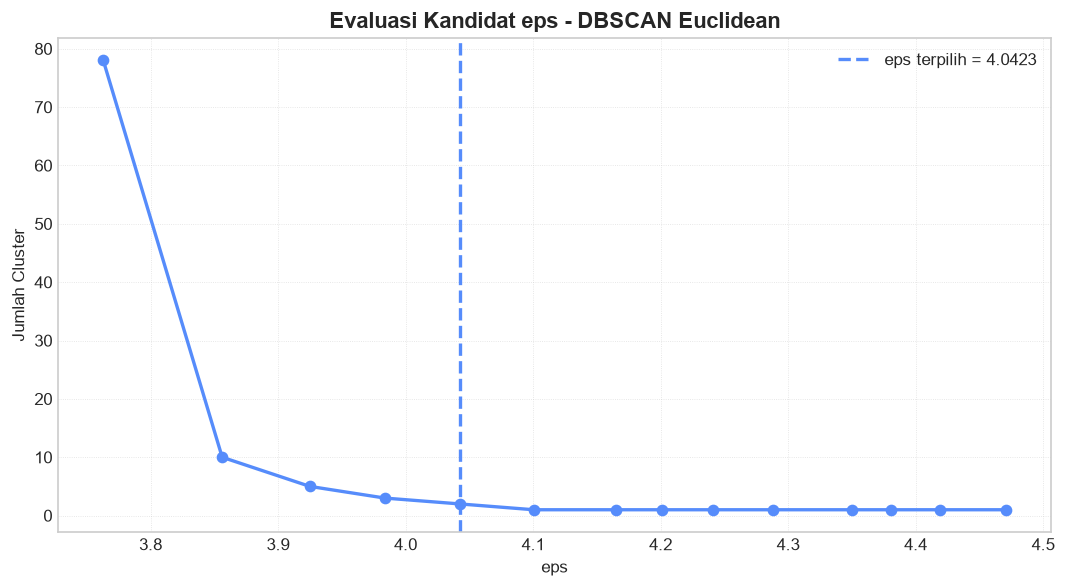

In [72]:
plt.figure(
    figsize=(9, 5)
)

plt.plot(
    eps_evaluation[
        'eps'
    ],
    eps_evaluation[
        'Jumlah Cluster'
    ],
    marker='o',
    linewidth=2
)

if eps is not None:

    plt.axvline(
        x=eps,
        linestyle='--',
        linewidth=2,
        label=(
            f'eps terpilih = '
            f'{eps:.4f}'
        )
    )

plt.title(
    'Evaluasi Kandidat eps - '
    'DBSCAN Euclidean',
    fontsize=13,
    fontweight='bold'
)

plt.xlabel('eps')
plt.ylabel('Jumlah Cluster')

plt.grid(
    True,
    linestyle=':',
    alpha=0.6
)

plt.legend()

plt.tight_layout()

plt.show()

3.2 Training DBSCAN Euclidian

In [73]:
if eps is None:
    raise ValueError(
        'Training tidak dapat dilanjutkan '
        'karena eps final belum ditemukan.'
    )

tracemalloc.start()

start_time = time.perf_counter()

dbscan = DBSCAN(
    eps=eps,
    min_samples=min_samples,
    metric='euclidean'
)

labels = dbscan.fit_predict(
    X_scaled
)

runtime = (
    time.perf_counter()
    - start_time
)

current_memory, peak_memory = (
    tracemalloc.get_traced_memory()
)

tracemalloc.stop()

peak_memory_mb = (
    peak_memory
    / (1024 ** 2)
)

df[
    'DBSCAN_Cluster'
] = labels

print(
    f'Runtime     : '
    f'{runtime:.5f} detik'
)

print(
    f'Peak Memory : '
    f'{peak_memory_mb:.2f} MB'
)

Runtime     : 3.33168 detik
Peak Memory : 34.53 MB


3.3 Identifikasi Cluster dan Noise

In [74]:
n_clusters = len(
    set(labels)
) - (
    1
    if -1 in labels
    else 0
)

n_noise = np.sum(
    labels == -1
)

noise_percentage = (
    n_noise
    / len(labels)
    * 100
)

n_core_points = len(
    dbscan.core_sample_indices_
)

print(
    f'Jumlah Cluster : '
    f'{n_clusters}'
)

print(
    f'Jumlah Noise   : '
    f'{n_noise}'
)

print(
    f'Persentase Noise: '
    f'{noise_percentage:.2f}%'
)

print(
    f'Core Points    : '
    f'{n_core_points}'
)

Jumlah Cluster : 2
Jumlah Noise   : 3309
Persentase Noise: 6.62%
Core Points    : 25000


4. Evaluasi

4.1 Silhouette Score

In [75]:
mask = labels != -1

X_valid = X_scaled.loc[
    mask
]

labels_valid = labels[
    mask
]

valid_cluster_count = len(
    np.unique(
        labels_valid
    )
)

if valid_cluster_count >= 2:

    silhouette = float(
        silhouette_score(
            X_valid,
            labels_valid,
            metric='euclidean'
        )
    )

else:

    silhouette = np.nan

print(
    f'Silhouette Score: '
    f'{silhouette:.4f}'
)

Silhouette Score: 0.2068


4.2 Davies-Bouldin Index

In [76]:
if valid_cluster_count >= 2:

    db_index = float(
        davies_bouldin_score(
            X_valid,
            labels_valid
        )
    )

else:

    db_index = np.nan

print(
    f'Davies-Bouldin Index: '
    f'{db_index:.4f}'
)

Davies-Bouldin Index: 1.5905


4.3 Calinski-Harabasz Index

In [77]:
if valid_cluster_count >= 2:

    ch_index = float(
        calinski_harabasz_score(
            X_valid,
            labels_valid
        )
    )

else:

    ch_index = np.nan

print(
    f'Calinski-Harabasz Index: '
    f'{ch_index:.2f}'
)

Calinski-Harabasz Index: 7019.23


4.4 Distribusi Cluster

In [78]:
cluster_distribution = (
    df[
        'DBSCAN_Cluster'
    ]
    .value_counts()
    .sort_index()
)

cluster_distribution

DBSCAN_Cluster
-1     3309
 0    41170
 1     5521
Name: count, dtype: int64

4.5 Ringkasan Evaluasi

In [79]:
model_summary = pd.DataFrame([{
    'Model':
        'DBSCAN Euclidean',

    'Distance Metric':
        'Euclidean Distance (L2)',

    'eps':
        round(
            eps,
            4
        ),

    'min_samples':
        min_samples,

    'Jumlah Cluster':
        n_clusters,

    'Jumlah Noise':
        n_noise,

    'Noise (%)':
        round(
            noise_percentage,
            2
        ),

    'Silhouette Score (↑)':
        round(
            silhouette,
            4
        ),

    'Davies-Bouldin Index (↓)':
        round(
            db_index,
            4
        ),

    'Calinski-Harabasz Index (↑)':
        round(
            ch_index,
            2
        ),

    'Execution Time (s) (↓)':
        round(
            runtime,
            5
        ),

    'Alokasi Memori (MB)':
        round(
            peak_memory_mb,
            2
        )
}])

model_summary

,Model,Distance Metric,eps,min_samples,Jumlah Cluster,Jumlah Noise,Noise (%),Silhouette Score (↑),Davies-Bouldin Index (↓),Calinski-Harabasz Index (↑),Execution Time (s) (↓),Alokasi Memori (MB)
0,DBSCAN Euclidean,Euclidean Distance (L2),4.0423,10,2,3309,6.62,0.2068,1.5905,7019.23,3.33168,34.53


4.6 Export Hasil

In [80]:
excel_path = os.path.join(
    OUTPUT_DIR,
    'evaluasi_dbscan_euclidean.xlsx'
)

df_clustered = df.copy()

df_clustered[
    'DBSCAN_Cluster'
] = labels

with pd.ExcelWriter(
    excel_path,
    engine='openpyxl'
) as writer:

    model_summary.to_excel(
        writer,
        sheet_name='Ringkasan_Evaluasi',
        index=False
    )

    df_clustered.to_excel(
        writer,
        sheet_name='Data_Terklaster',
        index=False
    )

print(
    f'Hasil disimpan ke: '
    f'{excel_path}'
)

Hasil disimpan ke: outputDBSCANEuclidian\evaluasi_dbscan_euclidean.xlsx


5. PCA

5.1 PCA

In [81]:
pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X_scaled
)

5.2 Visualisasi DBSCAN

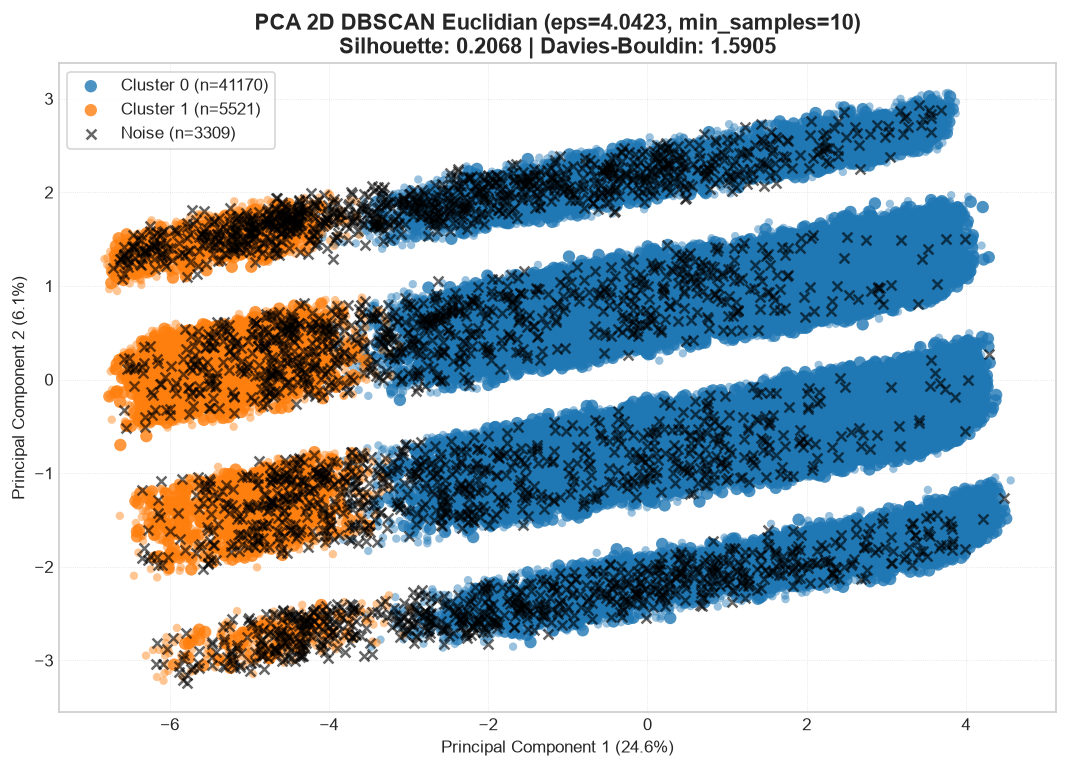

In [82]:
plt.figure(
    figsize=(9, 6.5)
)

palette = sns.color_palette(
    'tab10',
    max(
        n_clusters,
        1
    )
)

core_samples_mask = np.zeros(
    len(labels),
    dtype=bool
)

core_samples_mask[
    dbscan.core_sample_indices_
] = True

for k in range(
    n_clusters
):

    cluster_mask = (
        labels == k
    )

    core_mask = (
        cluster_mask
        & core_samples_mask
    )

    border_mask = (
        cluster_mask
        & ~core_samples_mask
    )

    # Core points
    plt.scatter(
        X_pca[
            core_mask,
            0
        ],
        X_pca[
            core_mask,
            1
        ],
        color=palette[k],
        s=55,
        alpha=0.80,
        edgecolors='none',
        label=(
            f'Cluster {k} '
            f'(n={np.sum(cluster_mask)})'
        )
    )

    # Border points
    plt.scatter(
        X_pca[
            border_mask,
            0
        ],
        X_pca[
            border_mask,
            1
        ],
        color=palette[k],
        s=25,
        alpha=0.45,
        edgecolors='none'
    )

# Noise
noise_mask = (
    labels == -1
)

plt.scatter(
    X_pca[
        noise_mask,
        0
    ],
    X_pca[
        noise_mask,
        1
    ],
    c='black',
    marker='x',
    s=35,
    alpha=0.60,
    label=(
        f'Noise '
        f'(n={np.sum(noise_mask)})'
    )
)

plt.title(
    f'PCA 2D DBSCAN Euclidian '
    f'(eps={eps:.4f}, '
    f'min_samples={min_samples})\n'
    f'Silhouette: '
    f'{silhouette:.4f} | '
    f'Davies-Bouldin: '
    f'{db_index:.4f}',
    fontsize=13,
    fontweight='bold'
)

plt.xlabel(
    'Principal Component 1 '
    f'('
    f'{pca.explained_variance_ratio_[0] * 100:.1f}%'
    f')'
)

plt.ylabel(
    'Principal Component 2 '
    f'('
    f'{pca.explained_variance_ratio_[1] * 100:.1f}%'
    f')'
)

plt.grid(
    True,
    linestyle=':',
    alpha=0.6
)

plt.legend(
    frameon=True,
    loc='best'
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        'cluster_dbscan_euclidian.png'
    ),
    dpi=300
)

plt.show()

6. Analisis

6.1 Profil Cluster

In [83]:
df_analysis = X.copy()

df_analysis[
    'DBSCAN_Cluster'
] = labels

cluster_profile = (
    df_analysis[
        df_analysis[
            'DBSCAN_Cluster'
        ] != -1
    ]
    .groupby(
        'DBSCAN_Cluster'
    )
    .median()
)

cluster_profile

,Age,Monthly_Income_USD,Work_Hours_Per_Week,Job_Satisfaction,Work_Life_Balance,Sleep_Hours,Anxiety_Score,Depression_Score,Mood_Score,Emotional_Stability,...,Stress_Level,Exercise_Frequency,Alcohol_Consumption,Smoking,Healthy_Diet,Chronic_Stress,Family_History_Mental_Illness,Therapy_Attendance,Support_System,Mental_Health_Status
DBSCAN_Cluster,,,,,,,,,,,,,,,,,,,,,
0,41.448181,6251.281524,41.0,5.499051,5.504397,7.1,34.0,34.0,66.0,67.0,...,0.0,2.0,0.0,0.0,1.0,0.0,0.0,1.000000,2.0,0.0
1,41.000000,6251.281524,62.0,6.000000,6.000000,6.0,83.0,83.0,18.0,17.0,...,2.0,2.0,1.0,0.0,1.0,1.0,1.0,0.504254,1.0,2.0


6.2 Perbandingan Cluster dengan Burnout Risk

In [84]:
comparison = pd.crosstab(
    df['DBSCAN_Cluster'],
    df['Burnout_Risk']
)

comparison

comparison_percentage = pd.crosstab(
    df['DBSCAN_Cluster'],
    df['Burnout_Risk'],
    normalize='index'
) * 100

comparison_percentage.round(
    2
)

Burnout_Risk,High,Low,Moderate
DBSCAN_Cluster,,,
-1,48.20,21.4,30.40
0,7.51,59.9,32.59
1,93.53,0.0,6.47


6.3 Analisis Noise

In [85]:
noise_data = df[
    df[
        'DBSCAN_Cluster'
    ] == -1
]

print(
    f'Jumlah Noise: '
    f'{len(noise_data)}'
)

print(
    f'Persentase Noise: '
    f'{len(noise_data) / len(df) * 100:.2f}%'
)

noise_data.head()

Jumlah Noise: 3309
Persentase Noise: 6.62%


,Person_ID,Age,Gender,Country,Occupation,Education_Level,Employment_Status,Monthly_Income_USD,Work_Hours_Per_Week,Remote_Work,...,Therapy_Attendance,Support_System,Life_Satisfaction,Productivity_Score,Absenteeism_Days,Burnout_Score,Mental_Health_Status,AI_Wellness_Recommendation,Burnout_Risk,DBSCAN_Cluster
4,5,64.0,Other,Japan,Farmer,Diploma,Student,NaN,52,No,...,No,Poor,9.0,61.0,4,26,Healthy,Reduce Workload,Low,-1
69,70,61.0,Other,Singapore,Student,PhD,Unemployed,4262.0,29,Yes,...,No,Average,9.0,70.0,24,19,Healthy,Take Regular Breaks,Low,-1
101,102,49.0,Female,Turkey,Farmer,Bachelor,Unemployed,4930.0,58,Yes,...,Yes,Average,4.0,38.0,10,68,Critical,Take Regular Breaks,High,-1
103,104,55.0,Other,France,Nurse,PhD,Self-Employed,1688.0,62,No,...,No,Average,3.0,17.0,30,79,Critical,Reduce Workload,High,-1
145,146,61.0,Other,India,Doctor,PhD,Employed,8307.0,56,No,...,Yes,Poor,8.0,50.0,19,33,Healthy,Increase Physical Activity,Low,-1
